In [2]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current folder:
c:\Users\sanja\OIBSIP\DataScience-Task5-SalesPrediction

Files in current folder:
['Advertising Budget and Sales.csv', 'Task5_Sales_Prediction.ipynb']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("Advertising Budget and Sales.csv")

print("Dataset loaded successfully! ✅")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset loaded successfully! ✅
Shape: (200, 5)
Columns: ['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Sales ($)']


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [6]:
# ==========================================
# DATA CLEANING
# ==========================================

# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Rename columns for easier Python usage
df = df.rename(columns={
    "TV Ad Budget ($)": "TV",
    "Radio Ad Budget ($)": "Radio",
    "Newspaper Ad Budget ($)": "Newspaper",
    "Sales ($)": "Sales"
})

print("Data cleaning completed! ✅")
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

df.head()

Data cleaning completed! ✅

Shape: (200, 4)

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [7]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


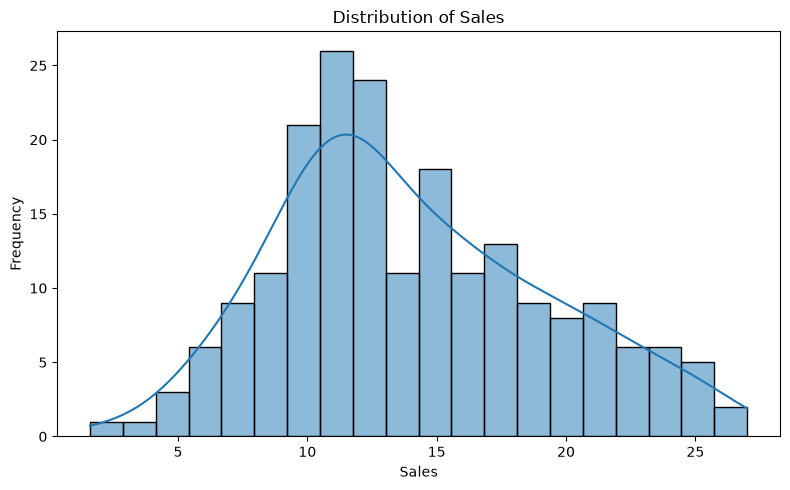

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Sales"],
    bins=20,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

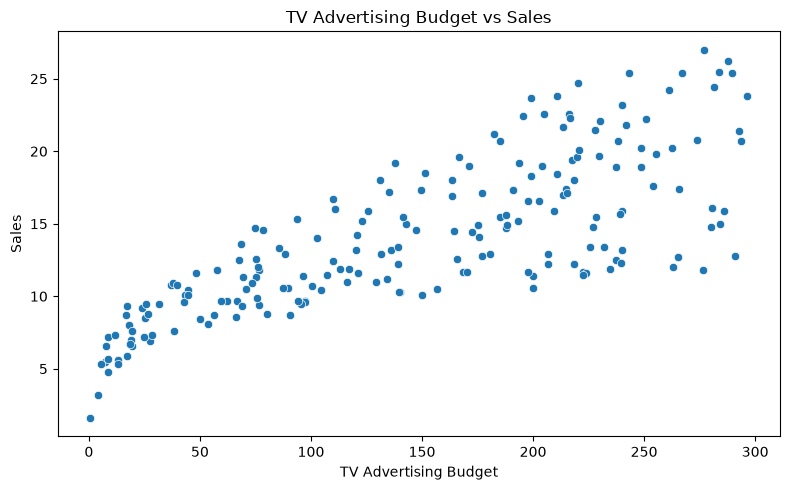

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("TV Advertising Budget vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

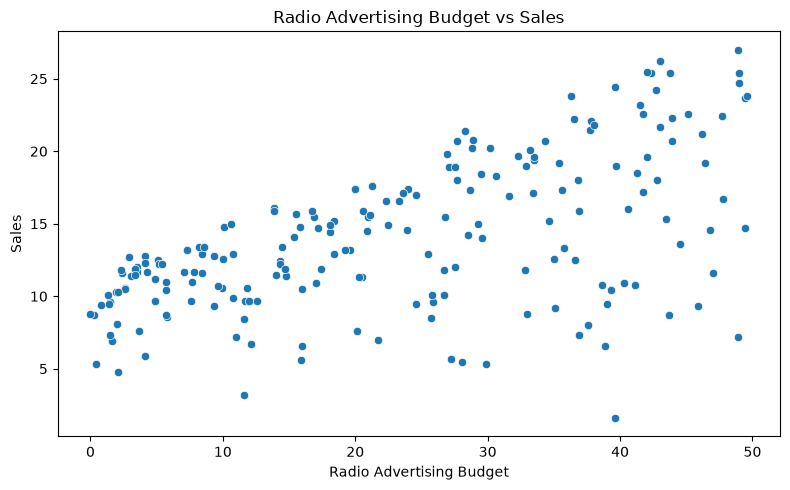

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales"
)

plt.title("Radio Advertising Budget vs Sales")
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

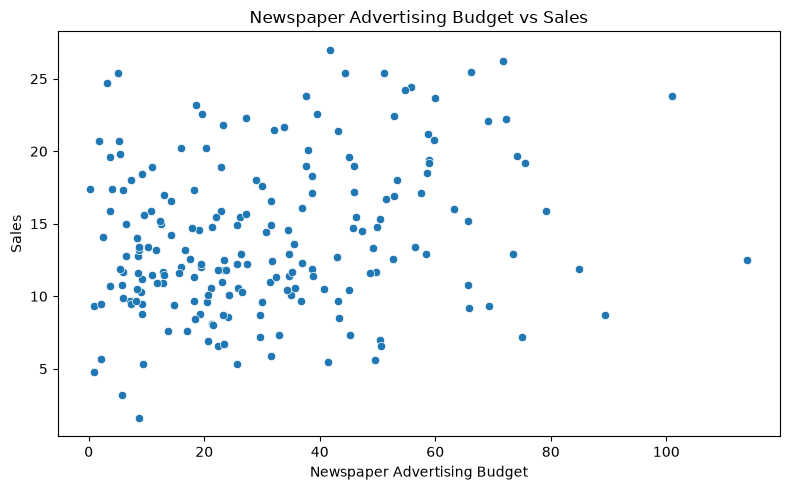

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales"
)

plt.title("Newspaper Advertising Budget vs Sales")
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

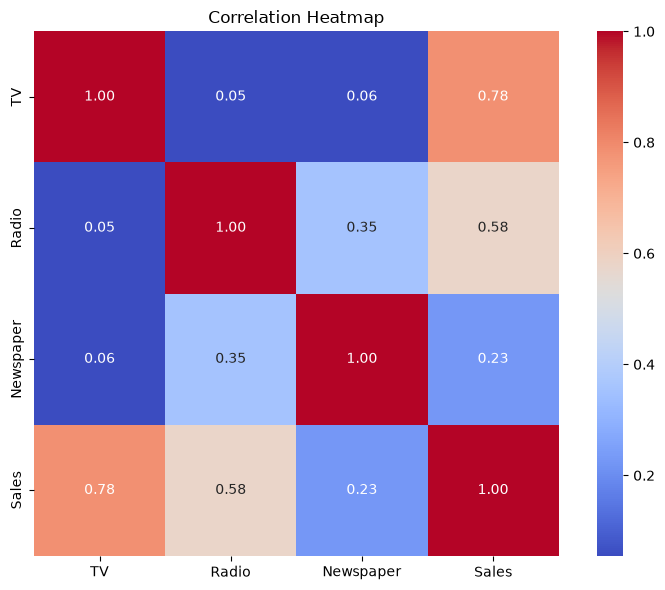

In [13]:
plt.figure(figsize=(8, 6))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

# Features
X = df[["TV", "Radio", "Newspaper"]]

# Target
y = df["Sales"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train/Test split completed! ✅")
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Train/Test split completed! ✅
Training samples: 160
Testing samples : 40


In [15]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression trained successfully! ✅")

Linear Regression trained successfully! ✅


In [16]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [17]:
print("Intercept:", linear_model.intercept_)

Intercept: 2.979067338122629


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully! ✅")

Random Forest trained successfully! ✅


In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [20]:
linear_mae = mean_absolute_error(
    y_test,
    y_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

linear_r2 = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression")
print("-------------------------")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

Linear Regression
-------------------------
MAE : 1.4608
RMSE: 1.7816
R²  : 0.8994


In [21]:
rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

rf_r2 = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest")
print("-------------------------")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))

Random Forest
-------------------------
MAE : 0.6289
RMSE: 0.7577
R²  : 0.9818


In [22]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

model_comparison.round(4)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.4608,1.7816,0.8994
1,Random Forest,0.6289,0.7577,0.9818


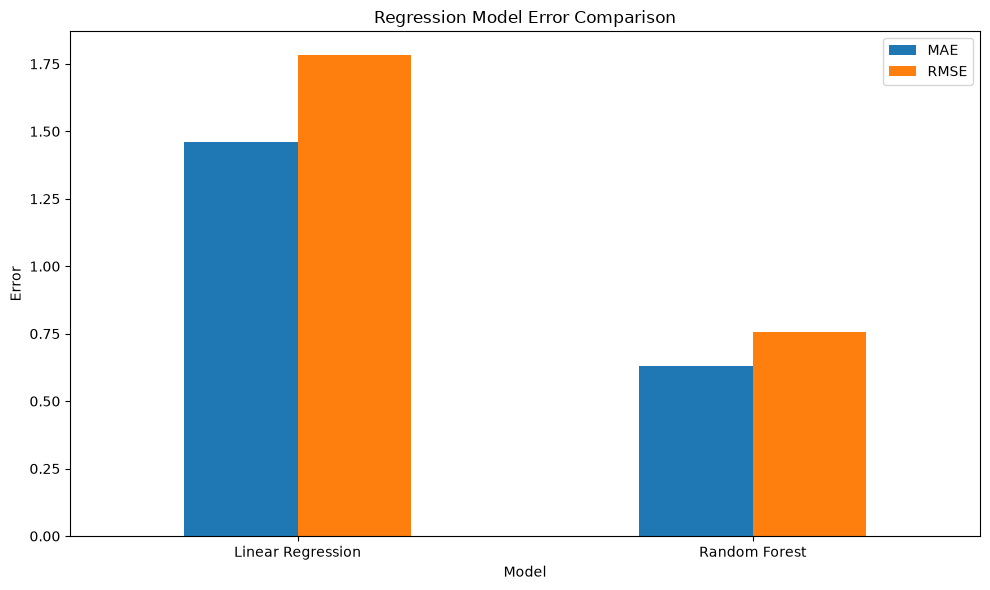

In [23]:
model_comparison.set_index("Model")[
    ["MAE", "RMSE"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Regression Model Error Comparison")
plt.xlabel("Model")
plt.ylabel("Error")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

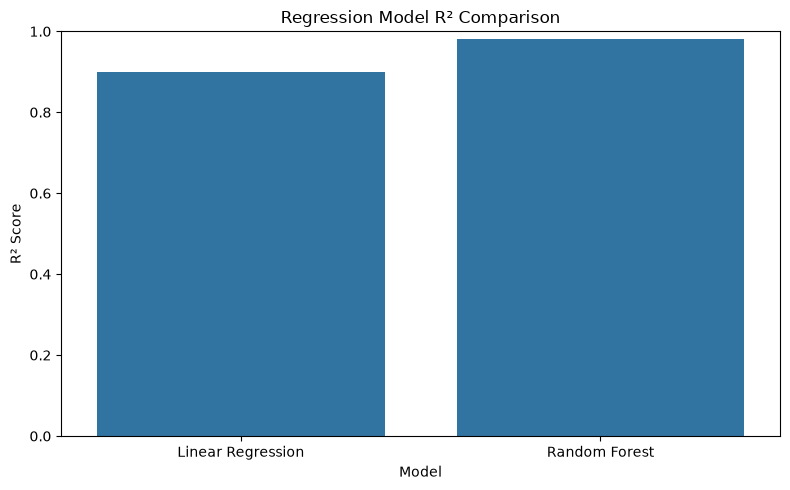

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Regression Model R² Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [25]:
if rf_r2 > linear_r2:
    best_model_name = "Random Forest"
    best_predictions = y_pred_rf
else:
    best_model_name = "Linear Regression"
    best_predictions = y_pred_linear

print("Best Performing Model:", best_model_name)

Best Performing Model: Random Forest


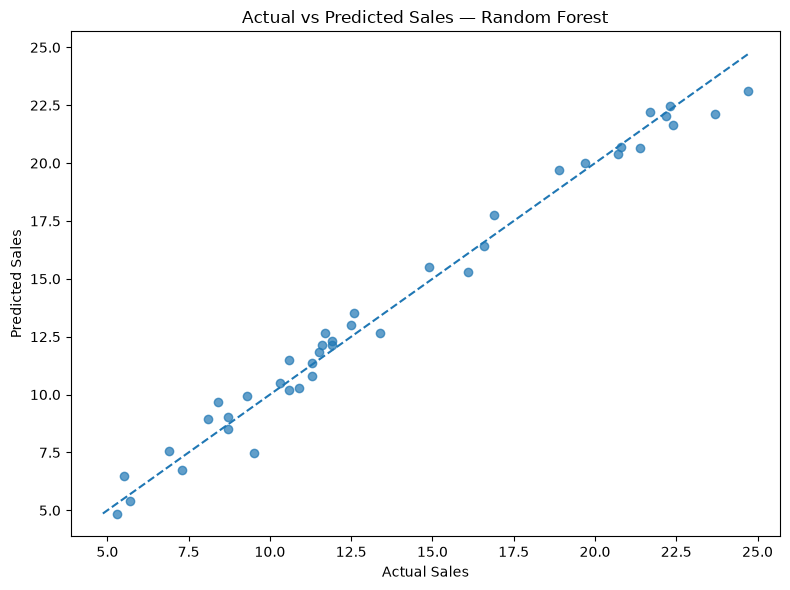

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

# Perfect prediction line
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(
    f"Actual vs Predicted Sales — {best_model_name}"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.show()

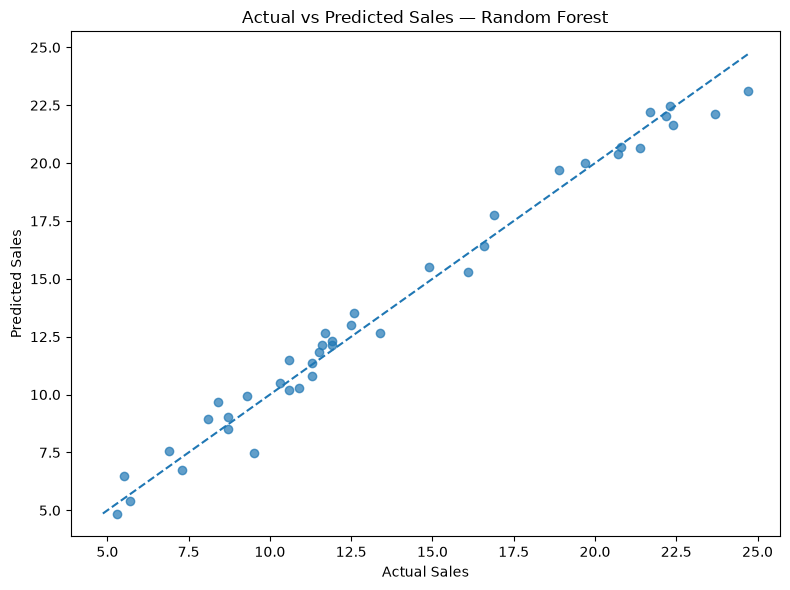

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

# Perfect prediction line
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(
    f"Actual vs Predicted Sales — {best_model_name}"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.show()

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624729
1,Radio,0.362129
2,Newspaper,0.013142


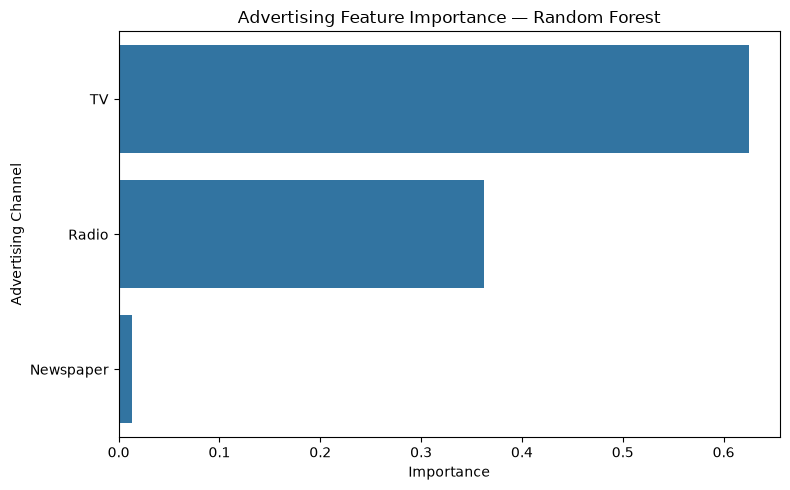

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Advertising Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.tight_layout()
plt.show()

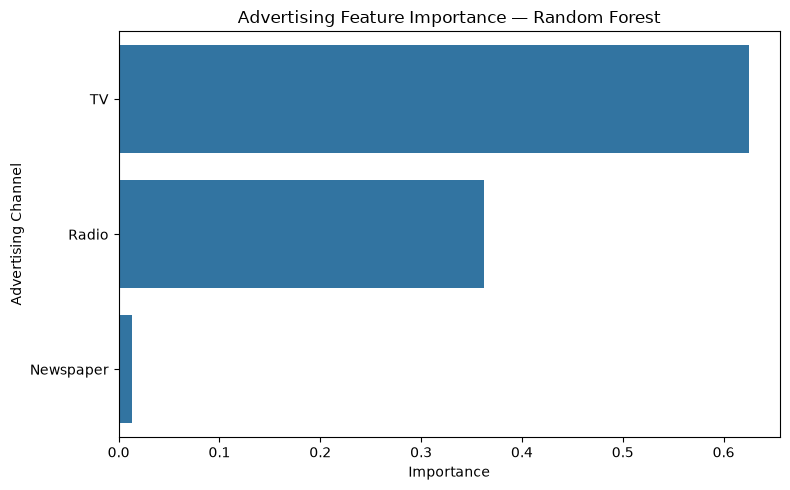

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Advertising Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.tight_layout()
plt.show()

In [31]:
# ==========================================
# FINAL MODEL RESULTS
# ==========================================

final_results = model_comparison.copy()

final_results["MAE"] = final_results["MAE"].round(4)
final_results["RMSE"] = final_results["RMSE"].round(4)
final_results["R2 Score"] = final_results["R2 Score"].round(4)

final_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.4608,1.7816,0.8994
1,Random Forest,0.6289,0.7577,0.9818


In [32]:
best_row = model_comparison.loc[
    model_comparison["R2 Score"].idxmax()
]

print("🏆 BEST PERFORMING MODEL")
print("==============================")
print("Model   :", best_row["Model"])
print("MAE     :", round(best_row["MAE"], 4))
print("RMSE    :", round(best_row["RMSE"], 4))
print("R² Score:", round(best_row["R2 Score"], 4))

🏆 BEST PERFORMING MODEL
Model   : Random Forest
MAE     : 0.6289
RMSE    : 0.7577
R² Score: 0.9818


In [34]:
new_ad_budget = pd.DataFrame({
    "TV": [200],
    "Radio": [40],
    "Newspaper": [30]
})

predicted_sales = rf_model.predict(new_ad_budget)[0]

print("💰 SAMPLE SALES PREDICTION")
print("==========================")
print("TV Advertising       : $200")
print("Radio Advertising    : $40")
print("Newspaper Advertising: $30")
print()
print("Predicted Sales      :", round(predicted_sales, 2))

💰 SAMPLE SALES PREDICTION
TV Advertising       : $200
Radio Advertising    : $40
Newspaper Advertising: $30

Predicted Sales      : 20.4


# Conclusion

This project developed a machine learning system to predict product sales based on advertising expenditure across TV, Radio, and Newspaper channels.

## Key Steps

- Loaded and inspected the advertising dataset
- Removed the unnecessary index column
- Renamed columns for easier analysis
- Performed exploratory data analysis
- Visualized relationships between advertising budgets and sales
- Analyzed correlations between variables
- Split the dataset into training and testing sets
- Built a Linear Regression baseline model
- Built a Random Forest Regression model
- Evaluated both models using MAE, RMSE, and R²
- Compared model performance
- Analyzed Random Forest feature importance
- Created actual vs predicted and residual plots
- Generated a sample sales prediction

## Model Evaluation

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Lower MAE and RMSE indicate smaller prediction errors, while a higher R² score indicates that the model explains more of the variation in sales.

## Best Performing Model

The model with the highest R² score was selected as the best-performing model.

The final model comparison and metrics are shown in the results table above.

## Advertising Channel Analysis

Random Forest feature importance was used to identify the advertising channel that contributed most strongly to the model's predictions.

This provides an indication of which advertising medium had the greatest predictive importance for sales within this dataset.

## Final Prediction

The trained model was also used to estimate sales for a hypothetical advertising budget consisting of:

- TV: $200
- Radio: $40
- Newspaper: $30

This demonstrates how the trained model can be used for future sales estimation based on advertising investment.

# Project Summary

| Component | Details |
|---|---|
| Problem | Sales prediction |
| Dataset | Advertising Budget & Sales Dataset |
| Samples | 200 |
| Features | TV, Radio, Newspaper |
| Target | Sales |
| Baseline Model | Linear Regression |
| Second Model | Random Forest Regression |
| Metrics | MAE, RMSE, R² |
| Visualization | Pairplot, scatter plots, heatmap, residual plot |
| Feature Analysis | Random Forest feature importance |
| Language | Python |
| Libraries | Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn |

# 📈 Sales Prediction Using Python

## Predicting Sales from Advertising Expenditure

### Objective

Build regression models to predict sales based on advertising expenditure across TV, Radio, and Newspaper channels.